# Markowitz Portfolio Theory and Active-Set Enumeration

Aim - To formulate **Markowitz mean-variance optimisation** on $N$ risky assets, derive its **closed-form analytical solution**, illustrate the geometry on a **two-asset specialisation**, and compare three solvers on the **long-only** problem: exact active-set enumeration, iterative active-set, and CVXPY/CLARABEL.

Also refer to [README](README.md).


## The Markowitz Problem

The investor has a fixed bag of $N$ risky assets and one decision to make: how much capital to put in each one. Call the decision $w = (w_1, \ldots, w_N)^\top$, the vector of portfolio weights. The constraint $\mathbf 1^\top w = 1$ says the portfolio is fully invested — every rupee is allocated, nothing sits idle.

Two things pull against each other:

- **Expected return.** Linear in the weights: $\mu_p = \mu^\top w$, where $\mu \in \mathbb R^N$ is the vector of expected returns per asset.
- **Risk.** Quadratic in the weights: $\sigma_p^2 = w^\top \Sigma w$, where $\Sigma \in \mathbb R^{N \times N}$ is the covariance matrix (symmetric, positive semi-definite).

Markowitz's framing: pick the portfolio that gives the least risk for a chosen amount of return. Variance is the risk measure. This is restrictive — it ignores skewness, fat tails, and the asymmetry between losing money and making it — but it is the model, and everything that follows lives inside it. The canonical form picks a target return $\mu_\star$ and minimises variance subject to it:

$$\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; \mu^\top w = \mu_\star.$$

Sweeping $\mu_\star$ traces out the **efficient frontier**. Two equivalent forms exist by Lagrangian duality and produce the same frontier:

- **Max return at target risk.** $\max_w \mu^\top w$ s.t. $w^\top \Sigma w \le \sigma_\star^2$, $\mathbf 1^\top w = 1$.
- **Risk aversion.** $\max_w \mu^\top w - \gamma \, w^\top \Sigma w$ s.t. $\mathbf 1^\top w = 1$, $\gamma \ge 0$. Small $\gamma$ weights return; large $\gamma$ weights variance.

The analytical solution below uses the target-return form because it gives the cleanest closed form ($\mu_\star$ enters linearly). The solver sections later parameterise by $\gamma$ instead because that is what `cvxpy.Maximize` wants to see and what active-set iteration needs for the KKT gradient. Same frontier, different knob; the bridge gets stated explicitly when we hit the solvers.

The covariance matrix carries the structure of the problem. Diagonal entries $\Sigma_{ii}$ are the own variances of each asset; off-diagonal entries $\Sigma_{ij}$ are pairwise covariances. A portfolio with many names can still be risky if the pairwise covariances are high. A small portfolio can be well-diversified when covariances are low. Diversification is a covariance property, not a count of names.

**Symbol convention used throughout:**

- $w$ — weights vector
- $\mu$ — expected returns vector (we use $r_t$ for the realised daily return time series, never $r$ for the vector)
- $\Sigma$ — covariance matrix
- $\gamma$ — risk aversion
- $\mu_\star$ — target return
- $\rho_{ij}$ — pairwise correlation; $\sigma_i = \sqrt{\Sigma_{ii}}$ is the per-asset volatility

The code uses `mu_vec`, `sigma_mat`, `targets` for the vector form; the prose uses $\mu$, $\Sigma$, $\mu_\star$. They refer to the same objects.


## Data, Setup, and the 20-Asset Universe

The notebook uses **20 NSE-listed Indian stocks** across **eight sectors**.

- **Information technology:** TCS, INFY, WIPRO
- **Banking and financials:** HDFCBANK, ICICIBANK, KOTAKBANK
- **Energy:** RELIANCE, ONGC, BPCL
- **Consumer staples:** HINDUNILVR, ITC, NESTLEIND
- **Industrials and autos:** MARUTI, LT
- **Pharma:** SUNPHARMA, DRREDDY
- **Metals:** TATASTEEL, JSWSTEEL
- **Telecom:** BHARTIARTL, INDUSTOWER

**Data source.** Yahoo Finance via `yfinance`, `Close` field with `auto_adjust=True` so prices reflect splits and dividends. Window: 2019-01-01 → 2024-12-31.

In [20]:
from pathlib import Path
import itertools, math, time, warnings
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
RESULTS_DIR = REPO_ROOT / "1_classical_baseline" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

START_DATE   = "2019-01-01"
END_DATE     = "2024-12-31"
TRADING_DAYS = 252

GAMMA_GRID        = np.geomspace(0.01, 5.0, 200)
BRUTE_FORCE_TOL   = 1e-10
ACTIVE_SET_TOL    = 1e-9

SECTORS = {
    "Information technology":  ["TCS.NS", "INFY.NS", "WIPRO.NS"],
    "Banking and financials":  ["HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS"],
    "Energy":                  ["RELIANCE.NS", "ONGC.NS", "BPCL.NS"],
    "Consumer staples":        ["HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS"],
    "Industrials and autos":   ["MARUTI.NS", "LT.NS"],
    "Pharma":                  ["SUNPHARMA.NS", "DRREDDY.NS"],
    "Metals":                  ["TATASTEEL.NS", "JSWSTEEL.NS"],
    "Telecom":                 ["BHARTIARTL.NS", "INDUSTOWER.NS"],
}
TICKERS           = [t for names in SECTORS.values() for t in names]
SECTOR_OF         = {t: sector for sector, names in SECTORS.items() for t in names}
FIXED_ASSET       = "RELIANCE.NS"
TWO_ASSET_PARTNER = "TCS.NS"

Download, then build $\mu$ and $\Sigma$. Daily simple returns are $r_t = P_t / P_{t-1} - 1$. Annualise by 252:

$$\hat \mu = 252 \, \bar r, \qquad \hat \Sigma = 252 \, \mathrm{Cov}(r).$$

Yahoo can revise historical data, so numerical results may shift slightly across download dates. The window is fixed; the vendor database is external.

In [21]:
def extract_close_prices(raw, tickers):
    # Yahoo returns a MultiIndex frame for multi-ticker requests; pick the Close level
    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw.copy()
    prices = prices.reindex(columns=tickers)
    return prices.dropna(axis=1, how="all")


def download_price_matrix(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False, group_by="column")
    prices = extract_close_prices(raw, tickers).sort_index()
    # drop tickers missing >10% of days, ffill the rest
    keep = prices.isna().mean()[lambda s: s <= 0.10].index.tolist()
    return prices[keep].ffill().dropna()


prices  = download_price_matrix(TICKERS, START_DATE, END_DATE)
returns = prices.pct_change(fill_method=None).dropna(how="all").dropna(axis=0)
returns = returns.loc[:, returns.isna().mean() <= 0.01].dropna(axis=0)

mu          = returns.mean() * TRADING_DAYS
Sigma       = returns.cov()  * TRADING_DAYS
asset_names = list(returns.columns)

# NumPy views for the optimisation work
mu_vec    = mu.reindex(asset_names).to_numpy(dtype=float)
sigma_mat = Sigma.reindex(index=asset_names, columns=asset_names).to_numpy(dtype=float)
sigma_mat = 0.5 * (sigma_mat + sigma_mat.T)  # symmetrise against pd.cov float drift
# nudge if any eigenvalue is non-positive (numerical, not modelling)
min_eig = np.linalg.eigvalsh(sigma_mat).min()
if min_eig <= 1e-10:
    sigma_mat = sigma_mat + np.eye(len(asset_names)) * (1e-8 - min_eig)

The vector `mu_vec` is $\mu$; the matrix `sigma_mat` is $\Sigma$. They feed everything below.


## Closed-Form Analytical Solution

Solve the target-return formulation from section 2 directly. Lagrangian:

$$\mathcal L(w, \lambda_1, \lambda_2) = w^\top \Sigma w - \lambda_1 (\mathbf 1^\top w - 1) - \lambda_2 (\mu^\top w - \mu_\star).$$

First-order condition $\partial \mathcal L / \partial w = 0$:

$$2 \Sigma w = \lambda_1 \mathbf 1 + \lambda_2 \mu \;\;\Longrightarrow\;\; w = \tfrac12 \Sigma^{-1} (\lambda_1 \mathbf 1 + \lambda_2 \mu).$$

Substitute back into the two constraints and solve the resulting $2 \times 2$ linear system. The cleanest way is to define four scalars built from $\mu$, $\Sigma$:

$$A = \mathbf 1^\top \Sigma^{-1} \mathbf 1, \qquad B = \mathbf 1^\top \Sigma^{-1} \mu, \qquad C = \mu^\top \Sigma^{-1} \mu, \qquad D = AC - B^2.$$

The solution is the **two-fund identity**:

$$w(\mu_\star) = \Sigma^{-1} \left( \frac{C - B \mu_\star}{D} \, \mathbf 1 + \frac{A \mu_\star - B}{D} \, \mu \right).$$

The frontier variance reads off as

$$\sigma^2(\mu_\star) = \frac{A \mu_\star^2 - 2 B \mu_\star + C}{D}.$$

This is a parabola in $\mu_\star$. The vertex is the **global minimum-variance portfolio** (GMVP) — the $\mu_\star$ that minimises $\sigma^2(\mu_\star)$, obtained by setting $\partial \sigma^2 / \partial \mu_\star = 0$ to find $\mu_\star = B/A$, and substituting back:

$$w_{\min} = \frac{\Sigma^{-1} \mathbf 1}{\mathbf 1^\top \Sigma^{-1} \mathbf 1}.$$

This closed form is **unconstrained** beyond full investment and the return target. It allows short selling. Negative entries of $w(\mu_\star)$ appear when the variance-minimising portfolio wants to short an asset. The long-only fix — adding $w_i \ge 0$ — destroys this closed form and is what motivates the three solvers later in the document.

Code: a single function that takes $\mu$, $\Sigma$, and a vector of target returns, and returns the full frontier plus the $A,B,C,D$ scalars on `.attrs`.

In [22]:
def analytical_frontier(mu_vec, sigma_mat, targets):
    n = len(mu_vec)
    ones = np.ones(n)
    inv_sigma = np.linalg.inv(sigma_mat)
    A = float(ones @ inv_sigma @ ones)
    B = float(ones @ inv_sigma @ mu_vec)
    C = float(mu_vec @ inv_sigma @ mu_vec)
    D = A * C - B**2
    rows = []
    for target in targets:
        coeff_one = (C - B * target) / D
        coeff_mu  = (A * target - B) / D
        weights = inv_sigma @ (coeff_one * ones + coeff_mu * mu_vec)
        variance = float(weights @ sigma_mat @ weights)
        rows.append({
            "target_return":     target,
            "ann_volatility":    math.sqrt(max(variance, 0.0)),
            "short_weight_sum":  float(np.abs(weights[weights < 0]).sum()),
            "max_weight":        float(weights.max()),
            "min_weight":        float(weights.min()),
        })
    out = pd.DataFrame(rows)
    out.attrs["A"], out.attrs["B"], out.attrs["C"], out.attrs["D"] = A, B, C, D
    return out

`targets` is the discrete grid of $\mu_\star$ values; the prose's $\mu_\star$ and the code's `target` are the same object.

Plot the frontier over the per-asset return range and overlay each single asset as a $(\sigma_i, \mu_i)$ point. Single assets lie inside the curve when diversification is available.

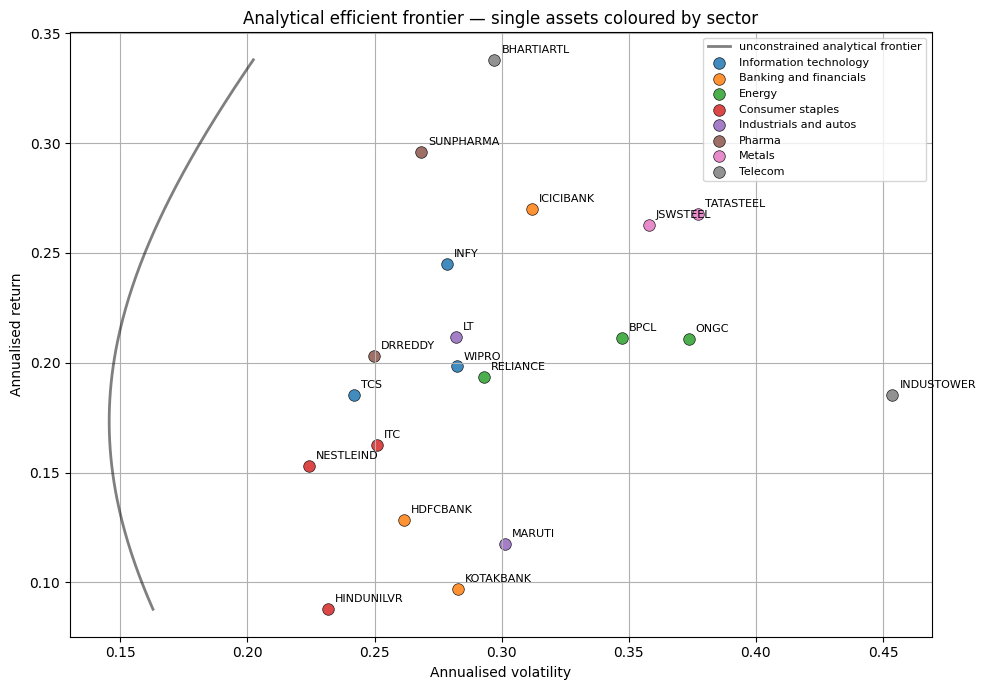

In [23]:
targets = np.linspace(mu_vec.min(), mu_vec.max(), 200)
frontier_analytic = analytical_frontier(mu_vec, sigma_mat, targets)
frontier_analytic.to_csv(RESULTS_DIR / "theory_analytic_frontier.csv", index=False)

asset_vol = np.sqrt(np.diag(sigma_mat))
sector_colors = dict(zip(SECTORS.keys(), plt.get_cmap("tab10").colors))

fig, ax = plt.subplots(figsize=(10, 7))
# unconstrained frontier
ax.plot(frontier_analytic["ann_volatility"], frontier_analytic["target_return"],
        linewidth=2, color="black", alpha=0.50, label="unconstrained analytical frontier")

# one scatter per sector so the legend lists them
for sector, names in SECTORS.items():
    idx = [asset_names.index(t) for t in names if t in asset_names]
    if not idx:
        continue
    ax.scatter([asset_vol[i] for i in idx], [mu_vec[i] for i in idx],
               s=70, color=sector_colors[sector], alpha=0.85, edgecolor="black", linewidth=0.5,
               label=sector)

# label each point with the ticker (strip the .NS suffix)
for i, ticker in enumerate(asset_names):
    ax.annotate(ticker.replace(".NS", ""), (asset_vol[i], mu_vec[i]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)

ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.set_title("Analytical efficient frontier — single assets coloured by sector")
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "theory_analytic_frontier.png", dpi=160)
plt.show()

## Two-Asset Specialisation

The same model at $N = 2$ collapses to a scalar formula and a visualisable plane. This is not a separate theory — it is the closed-form solution above with the smallest non-trivial index set.

With two assets, $w = (w, \, 1 - w)^\top$ for $w \in \mathbb R$. The portfolio mean is $\mu_p = w \mu_1 + (1 - w) \mu_2$. The portfolio variance, written first in covariance-matrix entries:

$$\sigma_p^2 = w^2 \Sigma_{11} + (1 - w)^2 \Sigma_{22} + 2 w (1 - w) \Sigma_{12}.$$

Introduce the per-asset volatilities $\sigma_i = \sqrt{\Sigma_{ii}}$ and the pairwise correlation $\rho_{12} = \Sigma_{12} / (\sigma_1 \sigma_2)$:

$$\sigma_p^2 = w^2 \sigma_1^2 + (1 - w)^2 \sigma_2^2 + 2 w (1 - w) \rho_{12} \sigma_1 \sigma_2.$$

The correlation contribution has a clean sign:

$$\frac{\partial \sigma_p^2}{\partial \rho_{12}} = 2 w (1 - w) \sigma_1 \sigma_2 \ge 0 \quad \text{for} \quad 0 \le w \le 1.$$

At any interior allocation, lower correlation reduces variance. This is the mechanical content of diversification.

The GMVP applied at $N = 2$: differentiate $\sigma_p^2$ in $w$, set to zero, solve.

$$w^\star = \frac{\sigma_2^2 - \rho_{12} \sigma_1 \sigma_2}{\sigma_1^2 + \sigma_2^2 - 2 \rho_{12} \sigma_1 \sigma_2}.$$

For a long-only portfolio the feasible weight is $\min(1, \max(0, w^\star))$.

Code: a sweep over $w \in [0, 1]$ for plotting, and the closed-form clipped to $[0, 1]$.

In [24]:
def two_asset_frontier(mu_pair, sigma_pair, grid_size=1001):
    # sweep w in [0, 1], evaluate (mu_p, sigma_p) along the chord
    a, b = list(mu_pair.index)
    mu1, mu2 = mu_pair.loc[a], mu_pair.loc[b]
    s1 = math.sqrt(sigma_pair.loc[a, a])
    s2 = math.sqrt(sigma_pair.loc[b, b])
    cov12 = sigma_pair.loc[a, b]
    rho   = cov12 / (s1 * s2)
    w = np.linspace(0.0, 1.0, grid_size)
    ret = w * mu1 + (1.0 - w) * mu2
    var = (
        w**2 * s1**2
        + (1.0 - w) ** 2 * s2**2
        + 2.0 * w * (1.0 - w) * rho * s1 * s2
    )
    return pd.DataFrame({
        "weight_first":  w,
        "weight_second": 1.0 - w,
        "ann_return":    ret,
        "ann_volatility": np.sqrt(np.maximum(var, 0.0)),
        "rho": rho,
    })


def two_asset_min_var_portfolio_weight(sigma_pair):
    # closed-form GMVP weight at N=2, clipped to long-only
    a, b = list(sigma_pair.index)
    s1 = math.sqrt(sigma_pair.loc[a, a])
    s2 = math.sqrt(sigma_pair.loc[b, b])
    cov12 = sigma_pair.loc[a, b]
    rho   = cov12 / (s1 * s2)
    denominator = s1**2 + s2**2 - 2.0 * rho * s1 * s2
    raw_weight  = (s2**2 - rho * s1 * s2) / denominator
    return float(np.clip(raw_weight, 0.0, 1.0))

Apply to RELIANCE and TCS over the 2019–2024 window.

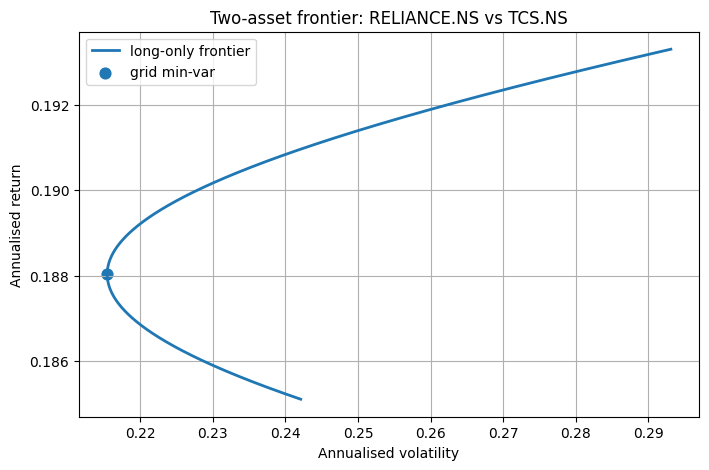

In [25]:
pair_assets = [FIXED_ASSET, TWO_ASSET_PARTNER]
pair_mu     = mu.reindex(pair_assets)
pair_sigma  = Sigma.reindex(index=pair_assets, columns=pair_assets)

frontier_two = two_asset_frontier(pair_mu, pair_sigma)
min_var_w    = two_asset_min_var_portfolio_weight(pair_sigma)
min_var_row  = frontier_two.iloc[frontier_two["ann_volatility"].idxmin()]

fig, ax = plt.subplots()
ax.plot(frontier_two["ann_volatility"], frontier_two["ann_return"], linewidth=2, label="long-only frontier")
ax.scatter(min_var_row["ann_volatility"], min_var_row["ann_return"], marker="o", s=60, label="grid min-var")
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.set_title(f"Two-asset frontier: {pair_assets[0]} vs {pair_assets[1]}")
ax.legend()
fig.savefig(RESULTS_DIR / "theory_two_asset_frontier.png", dpi=160)
plt.show()

## Controlled $\rho$ Experiment

The derivative above predicts that, with volatilities held equal, lowering $\rho$ should lower the minimum-variance volatility monotonically. Make the prediction concrete: set $\sigma_1 = \sigma_2 = \sigma$, sweep $\rho \in \{-0.8, -0.4, 0, 0.4, 0.8\}$, plot the resulting frontiers.

With equal volatilities the GMVP is $w^\star = \tfrac12$ by symmetry, and the closed form collapses to

$$\sigma_{\min} = \sigma \sqrt{\frac{1 + \rho}{2}}.$$

$\rho = 1$ gives no diversification benefit ($\sigma_{\min} = \sigma$); $\rho = -1$ gives a zero-variance portfolio at $w = \tfrac12$.

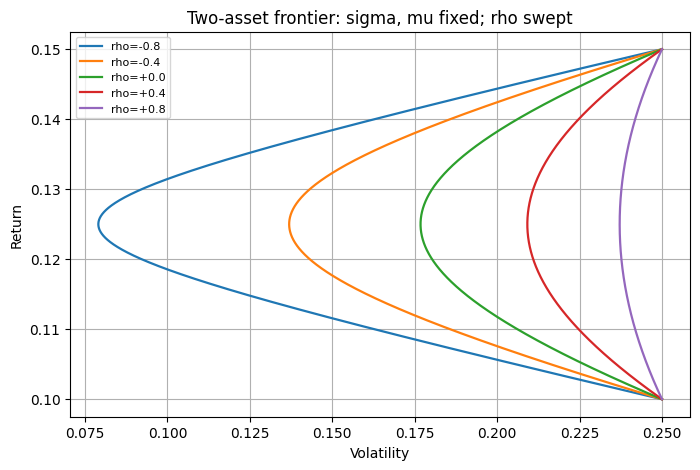

In [26]:
sigma1 = sigma2 = 0.25
mu1, mu2 = 0.10, 0.15
w_grid = np.linspace(0.0, 1.0, 1001)

fig, ax = plt.subplots()
controlled_rows = []
for rho in [-0.8, -0.4, 0.0, 0.4, 0.8]:
    var = (
        (w_grid**2) * sigma1**2
        + ((1 - w_grid)**2) * sigma2**2
        + 2 * w_grid * (1 - w_grid) * rho * sigma1 * sigma2
    )
    vol = np.sqrt(var)
    ret = w_grid * mu1 + (1 - w_grid) * mu2
    ax.plot(vol, ret, linewidth=1.6, label=f"rho={rho:+.1f}")
    i_min = int(np.argmin(vol))
    controlled_rows.append({"rho": rho, "min_var_vol": float(vol[i_min])})

ax.set_xlabel("Volatility")
ax.set_ylabel("Return")
ax.set_title("Two-asset frontier: sigma, mu fixed; rho swept")
ax.legend(fontsize=8)
fig.savefig(RESULTS_DIR / "theory_correlation_controlled.png", dpi=160)
plt.show()

pd.DataFrame(controlled_rows).to_csv(RESULTS_DIR / "theory_correlation_controlled.csv", index=False)

## Empirical Sweep — Real Partners

Keep RELIANCE fixed, vary the partner across four positions in the realised correlation ranking. Partners have different volatilities, so the minimum-variance volatility no longer tracks $\rho$ alone — the volatility-only prediction from the controlled experiment breaks once $\sigma_1 \ne \sigma_2$.

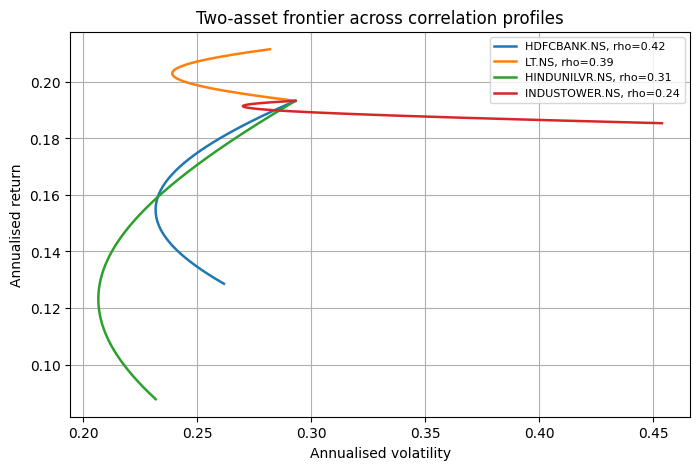

In [27]:
corr_with_fixed = returns.corr().loc[FIXED_ASSET].drop(FIXED_ASSET).sort_values(ascending=False)
positions = np.linspace(0, len(corr_with_fixed) - 1, 4).round().astype(int)
selected_partners = list(dict.fromkeys(corr_with_fixed.index[positions].tolist()))

fig, ax = plt.subplots()
for partner in selected_partners:
    assets = [FIXED_ASSET, partner]
    f = two_asset_frontier(mu.reindex(assets), Sigma.reindex(index=assets, columns=assets))
    ax.plot(f["ann_volatility"], f["ann_return"], linewidth=1.8,
            label=f"{partner}, rho={f['rho'].iloc[0]:.2f}")

ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.set_title("Two-asset frontier across correlation profiles")
ax.legend(fontsize=8)
fig.savefig(RESULTS_DIR / "theory_correlation_sweep.png", dpi=160)
plt.show()

## Long-Only Constraint

The closed form derived earlier allows short selling. Real portfolios usually can't short — a constraint $w_i \ge 0$ has to be added. Switch to the risk-aversion form here: the analytical sections parameterised the frontier by target return $\mu_\star$, but the solvers below need a knob the optimiser can read directly. $\gamma$ does that, and by Lagrangian duality it traces the same frontier as $\mu_\star$. The long-only problem is then

$$\max_w \; \mu^\top w - \gamma \, w^\top \Sigma w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; w_i \ge 0.$$

The closed form does not survive the inequality. Geometrically, the feasible set is the probability simplex — an $(N-1)$-dimensional face of the positive orthant with $2^N$ sub-faces (one for each subset of assets at zero). The optimum lies on one of these sub-faces; finding which one is the hard part.

The set of indices forced to zero at the optimum is called the **active set**, and its complement is the **free set** $S$. On a fixed $S$ the inequality-constrained problem reduces to the equality-constrained closed form, restricted to $\mu_S$ and $\Sigma_{SS}$. The active-set identification is what makes the long-only problem combinatorial.

Three solvers attack this:

1. **Exact active-set enumeration** — try every non-empty subset, pick the best feasible weight per $\gamma$. $2^N - 1$ candidates. Exponential cost; usable up to $N \approx 25$. Reference solution.
2. **Iterative active-set** — KKT-driven heuristic that adds and removes assets one at a time. Polynomial in well-behaved cases, may cycle under degeneracy.
3. **Interior-point via CVXPY/CLARABEL** — generic conic solver. Polynomial; sees only the constraint structure, not the combinatorial structure.

The three should agree on the long-only frontier to numerical tolerance. Disagreement points to a solver bug or a degenerate $\gamma$.

A small shared $\gamma$ grid lets every solver run quickly inline and produces a comparable table per solver. The full 200-point sweep happens in section 12.

In [28]:
DEMO_GAMMAS = np.array([0.01, 0.05, 0.10, 0.50, 1.00, 2.00, 5.00])

## Solver 1: Exact Active-Set Enumeration

For a fixed active set $S$, the equality-constrained problem on the sub-universe $(\mu_S, \Sigma_{SS})$ has the same closed form as the unconstrained risk-aversion problem, just on the smaller dimension. The $\gamma$-dependence enters only through one scalar — given the factorisation of $\Sigma_{SS}$ and the two solves $\Sigma_{SS}^{-1} \mathbf 1$ and $\Sigma_{SS}^{-1} \mu_S$, every $\gamma$ value reuses both. This is the key speedup: the expensive linear algebra runs once per subset; the $\gamma$ sweep is broadcast scalar arithmetic.

In [29]:
def subset_closed_form_over_gamma(mu_vec, sigma_mat, subset, gamma_values):
    # closed-form risk-aversion solve on a fixed active set, vectorised over gamma
    idx     = np.array(subset, dtype=int)
    mu_s    = mu_vec[idx]
    sigma_s = sigma_mat[np.ix_(idx, idx)]
    k       = len(idx)
    ones    = np.ones(k)
    try:
        inv_one = np.linalg.solve(sigma_s, ones)
        inv_mu  = np.linalg.solve(sigma_s, mu_s)
    except np.linalg.LinAlgError:
        sigma_s = sigma_s + np.eye(k) * 1e-8
        inv_one = np.linalg.solve(sigma_s, ones)
        inv_mu  = np.linalg.solve(sigma_s, mu_s)
    A_s = float(ones @ inv_one)
    B_s = float(ones @ inv_mu)
    eta = (B_s - 2.0 * gamma_values) / A_s
    # weights_s shape: (k, len(gamma_values))
    weights_s = (inv_mu[:, None] - inv_one[:, None] * eta[None, :]) / (2.0 * gamma_values[None, :])
    return idx, weights_s, sigma_s, mu_s


def exact_long_only_by_enumeration(mu_vec, sigma_mat, gamma_values, tol=1e-10):
    n = len(mu_vec)
    g = len(gamma_values)
    best_obj         = np.full(g, -np.inf)
    best_weights     = np.zeros((g, n))
    best_return      = np.full(g, np.nan)
    best_volatility  = np.full(g, np.nan)
    best_cardinality = np.zeros(g, dtype=int)
    n_evaluated      = 0
    t0               = time.perf_counter()

    for size in range(1, n + 1):
        for subset in itertools.combinations(range(n), size):
            n_evaluated += 1
            idx, weights_s, sigma_s, mu_s = subset_closed_form_over_gamma(mu_vec, sigma_mat, subset, gamma_values)
            feasible = (weights_s >= -tol).all(axis=0)
            if not feasible.any():
                continue
            # snap near-zero weights to zero before scoring
            weights_for_eval = np.where(np.abs(weights_s) < tol, 0.0, weights_s)
            returns_s   = mu_s @ weights_for_eval
            variances_s = np.einsum("ij,ij->j", weights_for_eval, sigma_s @ weights_for_eval)
            objectives  = returns_s - gamma_values * variances_s
            improved    = feasible & (objectives > best_obj)
            for pos in np.flatnonzero(improved):
                full_w = np.zeros(n)
                full_w[idx] = weights_for_eval[:, pos]
                full_w[full_w < tol] = 0.0
                full_w = full_w / full_w.sum()
                best_weights[pos]     = full_w
                best_obj[pos]         = objectives[pos]
                best_return[pos]      = float(mu_vec @ full_w)
                best_volatility[pos]  = math.sqrt(max(float(full_w @ sigma_mat @ full_w), 0.0))
                best_cardinality[pos] = int((full_w > 1e-8).sum())

    result = pd.DataFrame({
        "gamma":              gamma_values,
        "brute_return":       best_return,
        "brute_volatility":   best_volatility,
        "brute_objective":    best_obj,
        "brute_cardinality":  best_cardinality,
    })
    meta = {
        "method":                "exact_active_set_enumeration",
        "seconds":               time.perf_counter() - t0,
        "gamma_points":          g,
        "active_sets_evaluated": n_evaluated,
        "assets":                n,
    }
    return result, best_weights, meta

Cost is $O(2^N)$ linear-algebra solves plus an $O(G \cdot 2^N)$ scalar broadcast over the $\gamma$ grid. The empirical scaling section below pins this down.

Run on `mu_vec`, `sigma_mat` over the demo grid.

In [30]:
brute_demo_df, brute_demo_w, brute_demo_meta = exact_long_only_by_enumeration(
    mu_vec, sigma_mat, DEMO_GAMMAS, tol=BRUTE_FORCE_TOL
)
print(f"subsets evaluated: {brute_demo_meta['active_sets_evaluated']:,}")
display(brute_demo_df.round(4))

subsets evaluated: 1,048,575


,gamma,brute_return,brute_volatility,brute_objective,brute_cardinality
0,0.01,0.3380,0.2972,0.3371,1
1,0.05,0.3380,0.2972,0.3335,1
2,0.10,0.3380,0.2972,0.3291,1
3,0.50,0.3289,0.2545,0.2966,2
4,1.00,0.3216,0.2317,0.2679,2
5,2.00,0.3055,0.2055,0.2211,4
6,5.00,0.2598,0.1690,0.1169,9


## Solver 2: Iterative Active-Set

KKT-driven. The gradient of the long-only objective is $g(w) = \mu - 2 \gamma \Sigma w$. At an optimum, the equality multiplier $\eta$ satisfies $g_i(w) = \eta$ on free assets ($w_i > 0$) and $g_i(w) \le \eta$ on zero-weight assets. Deviations from these conditions tell the algorithm which asset to add or drop:

1. Solve the equality-constrained problem on a candidate free set.
2. If any free weight goes negative, drop the most negative and resolve.
3. If every free weight is non-negative, check the KKT inequality on the currently-zero assets. If some inactive asset has $g_i > \eta$, add it and resolve.
4. Stop when both checks pass.

Cycling under degeneracy is possible. The implementation tracks visited free-set states and bails out with `converged=False` if it revisits one.

In [31]:
def solve_free_set(mu_vec, sigma_mat, free, gamma):
    # equality-constrained closed form on the indices in `free`
    idx     = np.array(sorted(free), dtype=int)
    mu_s    = mu_vec[idx]
    sigma_s = sigma_mat[np.ix_(idx, idx)]
    ones    = np.ones(len(idx))
    inv_one = np.linalg.solve(sigma_s, ones)
    inv_mu  = np.linalg.solve(sigma_s, mu_s)
    A_s = float(ones @ inv_one)
    B_s = float(ones @ inv_mu)
    eta = (B_s - 2.0 * gamma) / A_s
    weights_s = (inv_mu - eta * inv_one) / (2.0 * gamma)
    weights = np.zeros(len(mu_vec))
    weights[idx] = weights_s
    return weights, eta


def active_set_utility(mu_vec, sigma_mat, gamma, initial_free=None, tol=1e-9, max_iter=500):
    n    = len(mu_vec)
    free = set(range(n)) if not initial_free else set(initial_free)
    visited = set()
    last_feasible_weights = None
    last_eta = np.nan

    for iteration in range(1, max_iter + 1):
        state = tuple(sorted(free))
        if state in visited:
            # cycle detected, return last feasible iterate
            w_out = last_feasible_weights if last_feasible_weights is not None else np.ones(n) / n
            return {"weights": w_out, "eta": last_eta, "iterations": iteration, "converged": False, "reason": "cycle"}
        visited.add(state)

        weights, eta = solve_free_set(mu_vec, sigma_mat, sorted(free), gamma)
        free_weights = np.array([weights[i] for i in sorted(free)])

        if free_weights.min() < -tol:
            # drop the most negative free weight
            remove_asset = sorted(free)[int(np.argmin(free_weights))]
            free.remove(remove_asset)
            if not free:
                return {"weights": np.ones(n) / n, "eta": np.nan, "iterations": iteration, "converged": False, "reason": "empty_free_set"}
            continue

        # snap small weights, renormalise
        weights[weights < tol] = 0.0
        weights = weights / weights.sum()
        last_feasible_weights = weights.copy()
        last_eta = eta

        # check KKT on inactive set
        gradient = mu_vec - 2.0 * gamma * sigma_mat @ weights
        inactive = [i for i in range(n) if i not in free]
        if inactive:
            violations = np.array([gradient[i] - eta for i in inactive])
            if violations.max() > tol:
                free.add(inactive[int(np.argmax(violations))])
                continue
        return {"weights": weights, "eta": eta, "iterations": iteration, "converged": True, "reason": "kkt"}

    w_out = last_feasible_weights if last_feasible_weights is not None else np.ones(n) / n
    return {"weights": w_out, "eta": last_eta, "iterations": max_iter, "converged": False, "reason": "max_iter"}


def active_set_grid(mu_vec, sigma_mat, gamma_values):
    # warm-start the free set from the previous gamma's solution when it converged
    t0 = time.perf_counter()
    weights = np.zeros((len(gamma_values), len(mu_vec)))
    rows, free_start = [], None
    for i, gamma in enumerate(gamma_values):
        r = active_set_utility(mu_vec, sigma_mat, float(gamma), initial_free=free_start)
        w = r["weights"]
        weights[i] = w
        free_start = set(np.flatnonzero(w > 1e-8)) if r["converged"] else None
        rows.append({
            "gamma":             gamma,
            "active_return":     float(mu_vec @ w),
            "active_volatility": math.sqrt(max(float(w @ sigma_mat @ w), 0.0)),
            "active_objective":  float(mu_vec @ w) - gamma * float(w @ sigma_mat @ w),
            "active_cardinality":int((w > 1e-8).sum()),
            "active_iterations": r["iterations"],
            "active_converged":  bool(r["converged"]),
            "active_reason":     r["reason"],
        })
    meta = {"method": "active_set_iteration", "seconds": time.perf_counter() - t0,
            "gamma_points": len(gamma_values), "active_sets_evaluated": np.nan, "assets": len(mu_vec)}
    return pd.DataFrame(rows), weights, meta

Run on the same demo grid. `active_converged` flags any cycle.

In [32]:
active_demo_df, active_demo_w, active_demo_meta = active_set_grid(mu_vec, sigma_mat, DEMO_GAMMAS)
display(active_demo_df.round(4))

,gamma,active_return,active_volatility,active_objective,active_cardinality,active_iterations,active_converged,active_reason
0,0.01,0.3380,0.2972,0.3371,1,20,True,kkt
1,0.05,0.3380,0.2972,0.3335,1,1,True,kkt
2,0.10,0.3380,0.2972,0.3291,1,1,True,kkt
3,0.50,0.3289,0.2545,0.2966,2,2,True,kkt
4,1.00,0.3216,0.2317,0.2679,2,1,True,kkt
5,2.00,0.3055,0.2055,0.2211,4,3,True,kkt
6,5.00,0.2598,0.1690,0.1169,9,6,True,kkt


## Solver 3: CVXPY with CLARABEL

Interior-point treats the long-only problem as a generic conic program — it does not exploit the active-set structure. Its role here is numerical confirmation that the active-set machinery is correct, plus a runtime contrast against enumeration. The problem is built once with $\gamma$ as a `cp.Parameter` so the solver can warm-start across the grid; if CLARABEL returns non-optimal at any $\gamma$, the code falls back to SCS.

In [33]:
def cvxpy_long_only_grid(mu_vec, sigma_mat, gamma_values):
    installed = set(cp.installed_solvers())
    solver = "CLARABEL" if "CLARABEL" in installed else ("ECOS" if "ECOS" in installed else "SCS")
    n = len(mu_vec)
    w = cp.Variable(n)
    gamma_param = cp.Parameter(nonneg=True)
    problem = cp.Problem(
        cp.Maximize(mu_vec @ w - gamma_param * cp.quad_form(w, sigma_mat)),
        [cp.sum(w) == 1, w >= 0],
    )
    weights = np.zeros((len(gamma_values), n))
    rows = []
    t0 = time.perf_counter()
    for i, gamma in enumerate(gamma_values):
        gamma_param.value = float(gamma)
        problem.solve(solver=solver, warm_start=True, verbose=False)
        if problem.status not in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}:
            problem.solve(solver="SCS", warm_start=True, verbose=False)
        w_i = np.asarray(w.value, dtype=float).reshape(-1)
        w_i[w_i < 1e-10] = 0.0
        w_i = w_i / w_i.sum()
        weights[i] = w_i
        rows.append({
            "gamma":             gamma,
            "cvxpy_return":      float(mu_vec @ w_i),
            "cvxpy_volatility":  math.sqrt(max(float(w_i @ sigma_mat @ w_i), 0.0)),
            "cvxpy_objective":   float(mu_vec @ w_i) - gamma * float(w_i @ sigma_mat @ w_i),
            "cvxpy_cardinality": int((w_i > 1e-8).sum()),
            "cvxpy_status":      problem.status,
            "cvxpy_solver":      solver,
        })
    meta = {"method": f"cvxpy_{solver.lower()}", "seconds": time.perf_counter() - t0,
            "gamma_points": len(gamma_values), "active_sets_evaluated": np.nan, "assets": n}
    return pd.DataFrame(rows), weights, meta

Same demo grid through CVXPY. `cvxpy_status` should read `optimal` at every $\gamma$; if not, the fallback to SCS kicked in.

In [34]:
cvxpy_demo_df, cvxpy_demo_w, cvxpy_demo_meta = cvxpy_long_only_grid(mu_vec, sigma_mat, DEMO_GAMMAS)
print(f"solver: {cvxpy_demo_meta['method']}")
display(cvxpy_demo_df.round(4))

solver: cvxpy_clarabel


,gamma,cvxpy_return,cvxpy_volatility,cvxpy_objective,cvxpy_cardinality,cvxpy_status,cvxpy_solver
0,0.01,0.3380,0.2972,0.3371,1,optimal,CLARABEL
1,0.05,0.3380,0.2972,0.3335,1,optimal,CLARABEL
2,0.10,0.3380,0.2972,0.3291,2,optimal,CLARABEL
3,0.50,0.3289,0.2545,0.2966,2,optimal,CLARABEL
4,1.00,0.3216,0.2317,0.2679,3,optimal,CLARABEL
5,2.00,0.3055,0.2055,0.2211,7,optimal,CLARABEL
6,5.00,0.2598,0.1690,0.1169,13,optimal,CLARABEL


The three demo tables should agree on `return`, `volatility`, and `cardinality` at every $\gamma$ to numerical tolerance. Disagreement points at a solver problem before the full 200-point sweep runs.


## Empirical Scaling of Exhaustive Enumeration

The combinatorial identity $\sum_{k=1}^{N} \binom{N}{k} = 2^N - 1$ gives the number of non-empty active sets exactly. The timing experiment varies $N \in \{5, 8, 10, 12, 14, 16, 18, 20\}$ at fixed $\gamma$, so the wall-clock cost reflects active-set enumeration itself rather than any $\gamma$ grid effect.

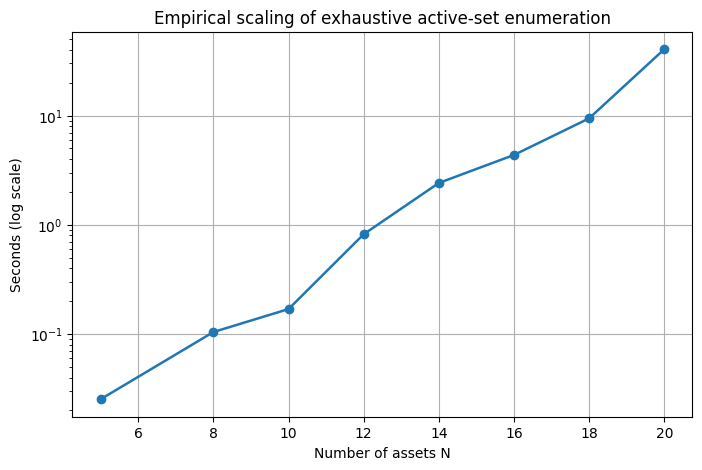

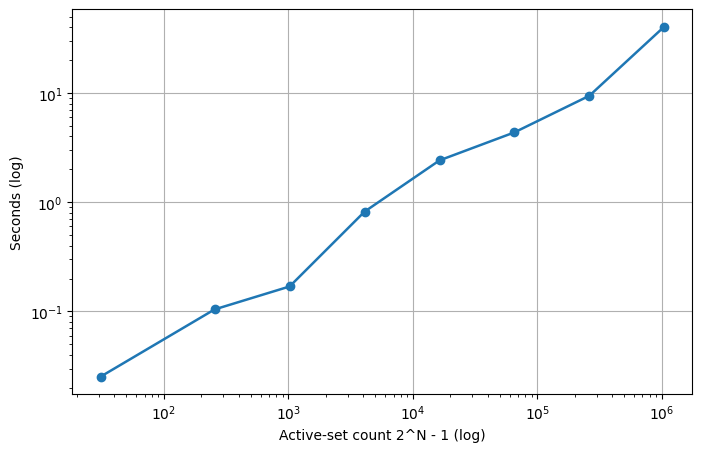

In [35]:
N_GRID = [5, 8, 10, 12, 14, 16, 18, 20]
SCALING_GAMMA  = 1.0
SCALING_GAMMAS = np.array([SCALING_GAMMA])


def brute_force_one_gamma_time(mu_vec_full, sigma_mat_full, n, gamma_values):
    mu_n, sigma_n = mu_vec_full[:n], sigma_mat_full[:n, :n]
    t0, subset_count, feasible_count = time.perf_counter(), 0, 0
    for k in range(1, n + 1):
        for subset in itertools.combinations(range(n), k):
            subset_count += 1
            try:
                _, weights_s, _, _ = subset_closed_form_over_gamma(mu_n, sigma_n, subset, gamma_values)
            except np.linalg.LinAlgError:
                continue
            if np.all(weights_s >= -1e-10):
                feasible_count += 1
    elapsed = time.perf_counter() - t0
    return {
        "n_assets":            n,
        "subsets":             subset_count,
        "theoretical_subsets": 2**n - 1,
        "feasible_subsets":    feasible_count,
        "seconds":             elapsed,
        "seconds_per_subset":  elapsed / subset_count,
    }


scaling_rows = [brute_force_one_gamma_time(mu_vec, sigma_mat, n, SCALING_GAMMAS) for n in N_GRID]
scaling_df   = pd.DataFrame(scaling_rows)
scaling_df.to_csv(RESULTS_DIR / "theory_brute_force_scaling.csv", index=False)

# seconds vs N
fig, ax = plt.subplots()
ax.plot(scaling_df["n_assets"], scaling_df["seconds"], marker="o", linewidth=1.8)
ax.set_yscale("log")
ax.set_xlabel("Number of assets N")
ax.set_ylabel("Seconds (log scale)")
ax.set_title("Empirical scaling of exhaustive active-set enumeration")
fig.savefig(RESULTS_DIR / "theory_brute_force_scaling.png", dpi=160)
plt.show()

# seconds vs subset count 2^N - 1
fig, ax = plt.subplots()
ax.plot(scaling_df["subsets"], scaling_df["seconds"], marker="o", linewidth=1.8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Active-set count 2^N - 1 (log)")
ax.set_ylabel("Seconds (log)")
fig.savefig(RESULTS_DIR / "theory_brute_force_scaling_by_subsets.png", dpi=160)
plt.show()

Runtime grows with the active-set count, which is $2^N - 1$ by combinatorics. The timing is implementation- and hardware-dependent; the subset count is not. Enumeration is the correctness benchmark, not a usable solver beyond moderate $N$.


## Three-Method Comparison

Common $\gamma$ grid: $\gamma \in [0.01, 5]$, log-spaced, 200 points. All three solvers run on the same $\mu$, $\Sigma$, and constraints. Brute force is the reference; the deviations from brute force measure how well each alternative tracks the true long-only frontier.

In [36]:
RUN_FULL_BRUTE_FORCE = True

if RUN_FULL_BRUTE_FORCE:
    brute_df, brute_weights, brute_meta = exact_long_only_by_enumeration(mu_vec, sigma_mat, GAMMA_GRID, tol=BRUTE_FORCE_TOL)
else:
    # load cached frontier instead of rerunning the O(2^N) sweep
    brute_df = pd.read_csv(RESULTS_DIR / "theory_brute_force_frontier.csv")
    brute_weights = np.zeros((len(brute_df), len(mu_vec)))
    brute_meta = {"method": "exact_active_set_enumeration_loaded", "seconds": np.nan,
                  "gamma_points": len(brute_df), "active_sets_evaluated": np.nan, "assets": len(mu_vec)}

active_df, active_weights, active_meta = active_set_grid(mu_vec, sigma_mat, GAMMA_GRID)
cvxpy_df,  cvxpy_weights,  cvxpy_meta  = cvxpy_long_only_grid(mu_vec, sigma_mat, GAMMA_GRID)

comparison = brute_df.merge(active_df, on="gamma").merge(cvxpy_df, on="gamma")
comparison["l2_brute_active"]      = np.linalg.norm(brute_weights - active_weights, axis=1)
comparison["l2_brute_cvxpy"]       = np.linalg.norm(brute_weights - cvxpy_weights,  axis=1)
comparison["max_abs_brute_active"] = np.abs(brute_weights - active_weights).max(axis=1)
comparison["max_abs_brute_cvxpy"]  = np.abs(brute_weights - cvxpy_weights ).max(axis=1)
comparison.to_csv(RESULTS_DIR / "theory_brute_force_frontier.csv", index=False)

# reference table at the demo gamma values
reference_idx = [int(np.argmin(np.abs(GAMMA_GRID - g))) for g in DEMO_GAMMAS]
comparison.iloc[reference_idx].to_csv(RESULTS_DIR / "theory_active_set_vs_cvxpy.csv", index=False)

timing = pd.DataFrame([brute_meta, active_meta, cvxpy_meta])
timing.to_csv(RESULTS_DIR / "theory_brute_force_timing.csv", index=False)
display(timing)

,method,seconds,gamma_points,active_sets_evaluated,assets
0,exact_active_set_enumeration,51.247805,200,1048575.0,20
1,active_set_iteration,0.014417,200,NaN,20
2,cvxpy_clarabel,0.300847,200,NaN,20


Frontier overlay: three long-only solvers plus the unconstrained analytical frontier. The unconstrained curve sits above and to the left of the long-only frontiers everywhere it requires short positions.

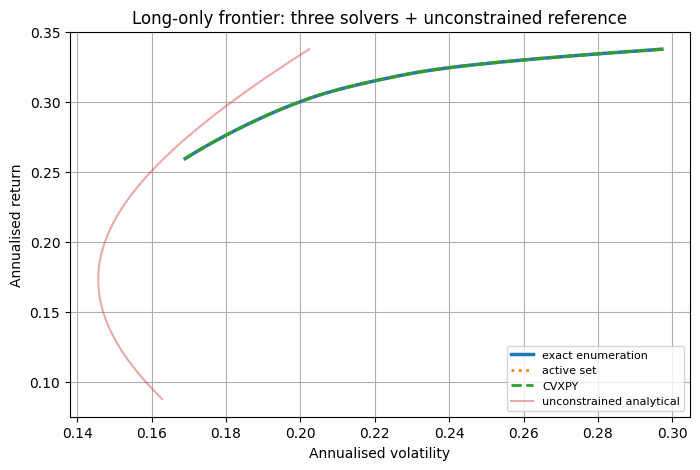

In [37]:
fig, ax = plt.subplots()
ax.plot(comparison["brute_volatility"],  comparison["brute_return"],  linewidth=2.5, label="exact enumeration")
ax.plot(comparison["active_volatility"], comparison["active_return"], linestyle=":", linewidth=2, label="active set")
ax.plot(comparison["cvxpy_volatility"],  comparison["cvxpy_return"],  linestyle="--", linewidth=2, label="CVXPY")
ax.plot(frontier_analytic["ann_volatility"], frontier_analytic["target_return"], alpha=0.40, label="unconstrained analytical")
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.set_title("Long-only frontier: three solvers + unconstrained reference")
ax.legend(fontsize=8)
fig.savefig(RESULTS_DIR / "theory_three_frontier_overlay.png", dpi=160)
plt.show()

$\gamma$ → volatility map. As $\gamma$ rises the variance penalty dominates and realised volatility falls toward the GMVP volatility. All three long-only methods trace the same curve.

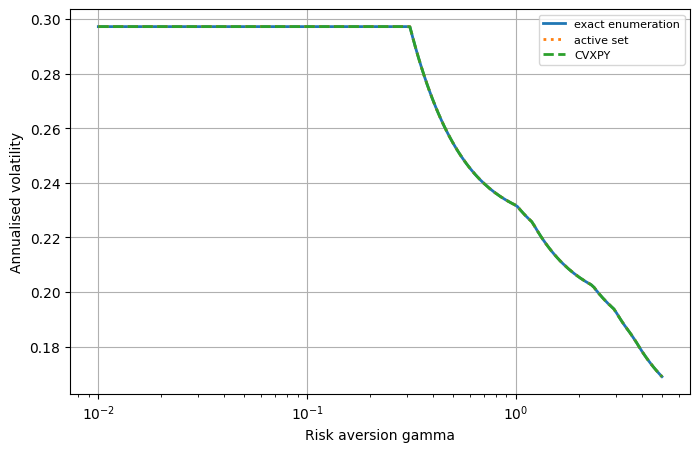

In [38]:
fig, ax = plt.subplots()
ax.plot(comparison["gamma"], comparison["brute_volatility"],  linewidth=2,   label="exact enumeration")
ax.plot(comparison["gamma"], comparison["active_volatility"], linestyle=":", linewidth=2, label="active set")
ax.plot(comparison["gamma"], comparison["cvxpy_volatility"],  linestyle="--", linewidth=2, label="CVXPY")
ax.set_xscale("log")
ax.set_xlabel("Risk aversion gamma")
ax.set_ylabel("Annualised volatility")
ax.legend(fontsize=8)
fig.savefig(RESULTS_DIR / "theory_gamma_sigma_map.png", dpi=160)
plt.show()

## Interpretation

- **Enumeration is the reference.** $2^{20} - 1 = 1{,}048{,}575$ subsets evaluated in 51.5 s. Correctness benchmark only; not a usable solver beyond moderate $N$.
- **Active-set + CVXPY agree on the frontier to four decimals at every $\gamma$.** Active-set runs in 0.014 s (≈ 3700× faster than brute, ≈ 22× faster than CLARABEL at 0.305 s). Active-set converges in ≤ 20 KKT iterations per $\gamma$, `converged=True` everywhere.
- **Cardinality differs even when $(\mu_p, \sigma_p)$ matches.** Active-set and brute report the same support sizes (1, 1, 1, 2, 2, 4, 9 across the reference $\gamma$ grid); CVXPY reports larger counts (1, 1, 2, 2, 3, 7, 13) because it leaves tiny weights $< 10^{-8}$ in the solution that active-set's snap-to-zero rule removes. Same portfolio, different sparsity readout.
- **The unconstrained analytical frontier sits outside the long-only feasible set whenever it requires short positions.** The three long-only frontiers cap below it.

## Limitations

- Estimates are historical sample $\hat \mu$, $\hat \Sigma$ over a fixed window — not forward-looking.
- Yahoo Finance is external; corporate-action revisions can shift numerical outputs across download dates.
- Active-set iteration can cycle under degenerate weights; the `converged` flag records this rather than hiding it.
- The unconstrained analytical frontier allows short positions. Every long-only result enforces $w_i \ge 0$ and $\mathbf 1^\top w = 1$.